In [1]:
import pandas as pd
import numpy as np
# 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
# 
from sklearn.model_selection import train_test_split
# 
from sklearn.ensemble import RandomForestClassifier
# 
from special_use_classes import OutlierHandling
import special_use_classes
import importlib
importlib.reload(special_use_classes)
# 
from sklearn.metrics import classification_report
# 
import matplotlib.pyplot as plt
import seaborn as sns
# 
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import  SMOTENC
outlier_handler = OutlierHandling()

In [2]:
df = pd.read_csv(r'data/df.csv')
df.head()

,Unnamed: 0,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,churn
0,0,existing customer,45,m,3,high school,married,$60k - $80k,blue,39,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,NaN
1,1,existing customer,49,f,5,graduate,single,less than $40k,blue,44,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,NaN
2,2,existing customer,51,m,3,graduate,married,$80k - $120k,blue,36,...,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,NaN
3,3,existing customer,40,f,4,high school,unknown,less than $40k,blue,34,...,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,NaN
4,4,existing customer,40,m,3,uneducated,married,$60k - $80k,blue,21,...,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,NaN


In [3]:
if('Unnamed: 0' in df.columns.tolist()):
    df.drop(columns='Unnamed: 0', inplace=True)
    print('deteled redundant column')
else:
    print('column not found')
df.head()

deteled redundant column


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,churn
0,existing customer,45,m,3,high school,married,$60k - $80k,blue,39,5,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,NaN
1,existing customer,49,f,5,graduate,single,less than $40k,blue,44,6,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,NaN
2,existing customer,51,m,3,graduate,married,$80k - $120k,blue,36,4,...,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,NaN
3,existing customer,40,f,4,high school,unknown,less than $40k,blue,34,3,...,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,NaN
4,existing customer,40,m,3,uneducated,married,$60k - $80k,blue,21,5,...,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,NaN


In [4]:
df['churn'] = df['Attrition_Flag'].map({'existing customer': 0, 'attrited customer': 1})

df['churn']

0        0
1        0
2        0
3        0
4        0
        ..
10122    0
10123    1
10124    1
10125    1
10126    1
Name: churn, Length: 10127, dtype: int64

In [5]:
# so that my target variable is churn 0 for existing and 1 for attrited 

In [6]:
sample = df.sample(frac=.1, random_state=42)

In [7]:
# lets do churn prediction

In [8]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1013 entries, 3781 to 7937
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            1013 non-null   object 
 1   Customer_Age              1013 non-null   int64  
 2   Gender                    1013 non-null   object 
 3   Dependent_count           1013 non-null   int64  
 4   Education_Level           1013 non-null   object 
 5   Marital_Status            1013 non-null   object 
 6   Income_Category           1013 non-null   object 
 7   Card_Category             1013 non-null   object 
 8   Months_on_book            1013 non-null   int64  
 9   Total_Relationship_Count  1013 non-null   int64  
 10  Months_Inactive_12_mon    1013 non-null   int64  
 11  Contacts_Count_12_mon     1013 non-null   int64  
 12  Credit_Limit              1013 non-null   float64
 13  Total_Revolving_Bal       1013 non-null   int64  
 14  Avg_Open_T

In [9]:
sample.head().to_clipboard()

In [10]:
# i decided to use tree models for churn because highly correlated features are also important in this context

In [11]:
df.columns[0]

'Attrition_Flag'

In [12]:
encoded_df = pd.get_dummies(df.drop('Attrition_Flag', axis=1), drop_first=True)
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Customer_Age                    10127 non-null  int64  
 1   Dependent_count                 10127 non-null  int64  
 2   Months_on_book                  10127 non-null  int64  
 3   Total_Relationship_Count        10127 non-null  int64  
 4   Months_Inactive_12_mon          10127 non-null  int64  
 5   Contacts_Count_12_mon           10127 non-null  int64  
 6   Credit_Limit                    10127 non-null  float64
 7   Total_Revolving_Bal             10127 non-null  int64  
 8   Avg_Open_To_Buy                 10127 non-null  float64
 9   Total_Amt_Chng_Q4_Q1            10127 non-null  float64
 10  Total_Trans_Amt                 10127 non-null  int64  
 11  Total_Trans_Ct                  10127 non-null  int64  
 12  Total_Ct_Chng_Q4_Q1             

In [13]:
X = encoded_df.drop('churn', axis=1)
y = encoded_df['churn']

# removing highly redundant feature
X = X.drop('Avg_Open_To_Buy', axis=1)

X.head()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,...,Marital_Status_single,Marital_Status_unknown,Income_Category_$40k - $60k,Income_Category_$60k - $80k,Income_Category_$80k - $120k,Income_Category_less than $40k,Income_Category_unknown,Card_Category_gold,Card_Category_platinum,Card_Category_silver
0,45,3,39,5,1,3,12691.0,777,1.335,1144,...,False,False,False,True,False,False,False,False,False,False
1,49,5,44,6,1,2,8256.0,864,1.541,1291,...,True,False,False,False,False,True,False,False,False,False
2,51,3,36,4,1,0,3418.0,0,2.594,1887,...,False,False,False,False,True,False,False,False,False,False
3,40,4,34,3,4,1,3313.0,2517,1.405,1171,...,False,True,False,False,False,True,False,False,False,False
4,40,3,21,5,1,0,4716.0,0,2.175,816,...,False,False,False,True,False,False,False,False,False,False


In [14]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 , stratify=y)






In [15]:
mymodel = RandomForestClassifier(n_estimators=100, random_state=42)
mymodel.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [16]:
# to get a classification report first i have to predict using model and store 
mypredictions = mymodel.predict(X_test)

print(
    
    classification_report(y_test, mypredictions ) # always true data in the first
    
)

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1701
           1       0.92      0.77      0.84       325

    accuracy                           0.95      2026
   macro avg       0.94      0.88      0.91      2026
weighted avg       0.95      0.95      0.95      2026



In [17]:
# showing data balance
counts = y_train.value_counts()
print(counts)


churn
0    6799
1    1302
Name: count, dtype: int64


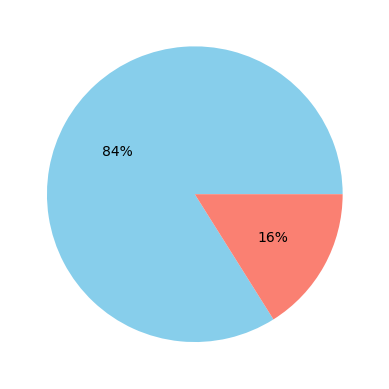

In [18]:
plt.pie(counts, autopct='%.f%%', colors=['skyblue','salmon'])
plt.show()

In [19]:
# # to solve unbalanced data
# # lets do the smote sampling but with smotenc becaues we also have boolean columns


# first we get a mask true/false for every column that is boolean
bool_cols_tf = X_train.dtypes == 'bool'
# then we make a dataframe out of it to get the indieces
thing2 = pd.DataFrame({'cols':bool_cols_tf.index, 'value':bool_cols_tf.values})

bool_indecies = thing2[thing2['value'] == True].index.tolist()
# bool_indecies.tolist()
smote_nc = SMOTENC(categorical_features= bool_indecies , random_state=42)

X_train_smote, y_train_smote = smote_nc.fit_resample(X_train, y_train)



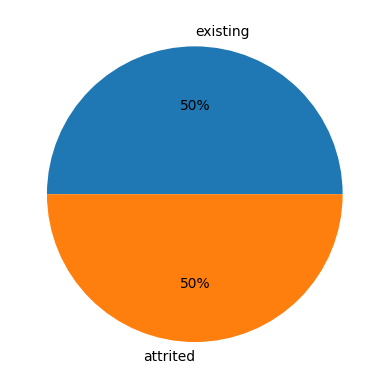

churn
0    6799
1    6799
Name: count, dtype: int64

In [34]:
plt.pie(y_train_smote.value_counts(), autopct="%.f%%", labels=['existing','attrited'])
plt.show()
y_train_smote.value_counts()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model2.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [36]:
from sklearn.metrics import classification_report

preds = model2.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1701
           1       0.86      0.85      0.85       325

    accuracy                           0.95      2026
   macro avg       0.91      0.91      0.91      2026
weighted avg       0.95      0.95      0.95      2026



              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1701
           1       0.86      0.85      0.85       325

    accuracy                           0.95      2026
   macro avg       0.91      0.91      0.91      2026
weighted avg       0.95      0.95      0.95      2026

[[1655   46]
 [  49  276]]
ROC-AUC: 0.9110939266494822


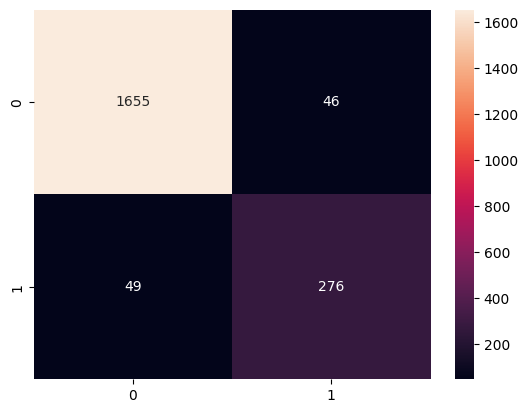

In [37]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))
sns.heatmap(confusion_matrix(y_test, preds), annot=True,fmt='d')

print("ROC-AUC:", roc_auc_score(y_test, preds))

In [38]:
importance = pd.DataFrame({
    
    'Feature': X.columns,
    'Importance': mymodel.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                     Feature  Importance
9            Total_Trans_Amt    0.184632
10            Total_Trans_Ct    0.159317
11       Total_Ct_Chng_Q4_Q1    0.104753
7        Total_Revolving_Bal    0.095861
12     Avg_Utilization_Ratio    0.077324
3   Total_Relationship_Count    0.070327
8       Total_Amt_Chng_Q4_Q1    0.065941
6               Credit_Limit    0.040554
0               Customer_Age    0.033570
5      Contacts_Count_12_mon    0.029483


In [39]:
importance2 = pd.DataFrame(
    {
        'columns' : X_train.columns,
        'importance' : model2.feature_importances_
    }
)
print(importance2.sort_values(by='importance', ascending=False).head())

                  columns  importance
10         Total_Trans_Ct    0.210713
9         Total_Trans_Amt    0.201918
7     Total_Revolving_Bal    0.097365
11    Total_Ct_Chng_Q4_Q1    0.094936
12  Avg_Utilization_Ratio    0.067670


In [ ]:
from sklearn.metrics import roc_auc_score



probs = model2.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, probs)

print(roc_auc)

0.9817862795640573
